# **Reconocimiento de Patrones**

## **Práctica 2: Extracción de características**

**Nombre:** Pérez Aguiar Oropeza Gabriel Emiliano

### **1. Descarga y organiza un conjunto de imágenes**

Se utilizará el conjunto de datos Flickr Material Database (FMD) encontrado en kaggle.

In [2]:
# Instalamos la biblioteca kagglehub para importar datasets de Kaggle.
!pip install kagglehub

In [3]:
# Bibliotecas necesarias para importar y organizar el conjunto de datos
import kagglehub
import os
import glob

/home/emi/anaconda3/envs/mainn/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Descargamos el conjunto de datos y definimos el directorio donde están las imágenes
path = kagglehub.dataset_download("liewyousheng/flickr-material-database")
img_dir = os.path.join(path, 'image')

# Definimos los tipos de texturas en el conjunto (estos ya están organizados en carpetas)
categories = [d for d in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, d))]
print(f"Categorías encontradas: {categories}")

# Finalmente, creamos un diccionario con las rutas de las imágenes por categoría
map = {}
for cat in categories:
    map[cat] = glob.glob(os.path.join(img_dir, cat, "*.jpg"))

print(f"\nImágenes encontradas por categoría:\n")
for cat in categories:
    print(f"{cat}: {len(map[cat])} imágenes")

Categorías encontradas: ['wood', 'water', 'paper', 'leather', 'glass', 'stone', 'plastic', 'fabric', 'metal', 'foliage']

Imágenes encontradas por categoría:

wood: 100 imágenes
water: 100 imágenes
paper: 100 imágenes
leather: 100 imágenes
glass: 100 imágenes
stone: 100 imágenes
plastic: 100 imágenes
fabric: 100 imágenes
metal: 100 imágenes
foliage: 100 imágenes


### **2. Carga las imágenes y conviértelas a escala de grises**

Muestra una imagen y su histograma por cada clase.

In [5]:
# Bibliotecas necesarias para el procesamiento de imágenes
import numpy as np
import matplotlib.pyplot as plt
import cv2

Iniciando la carga de imágenes...
Carga completada.

Dimensiones de la primer imagen en 'wood': (384, 512, 3)


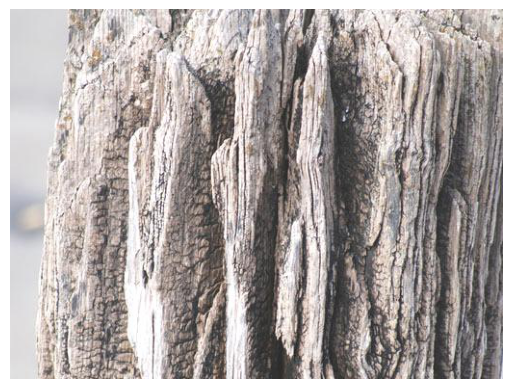

In [6]:
# Cargamos las imágenes utilizando OpenCV

# Diccionario para almacenar las imágenes
images = {}

print("Iniciando la carga de imágenes...")

# Cargamos las imágenes en formato RGB
for cat, file_list in map.items():
    images[cat] = []
    for img_path in file_list:
        img = cv2.imread(img_path)[:, :, ::-1]    
        images[cat].append(img)
        
print(f"Carga completada.\n")

# Visualizamos la primer imagen de la primer categoría, así como sus dimensiones
print(f"Dimensiones de la primer imagen en '{categories[0]}': {images[categories[0]][0].shape}")
plt.imshow(images[categories[0]][0])
#plt.title("Imagen de ejemplo en la categoría " + categories[0], fontsize=14)
plt.axis('off')
plt.show()


Iniciando la conversión a escala de grises...
Conversión a escala de grises completada.

Dimensiones de la imagen anterior en escala de grises: (384, 512)


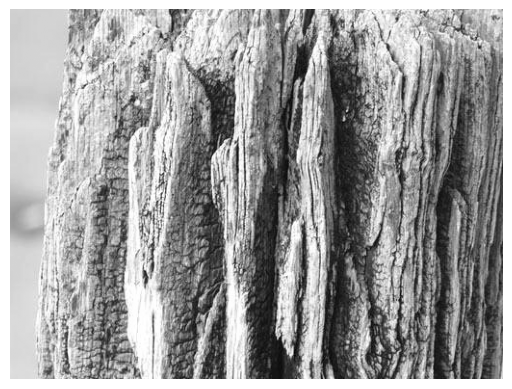

In [7]:
# Convertimos las imágenes a escala de grises
gray_images = {}

print("Iniciando la conversión a escala de grises...")

for cat, img_list in images.items():
    gray_images[cat] = [cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in img_list]

print(f"Conversión a escala de grises completada.\n")

# Visualizamos la imagen anterior, ahora en escala de grises, así como sus dimensiones
print(f"Dimensiones de la imagen anterior en escala de grises: {gray_images[categories[0]][0].shape}")
plt.imshow(gray_images[categories[0]][0], cmap='gray')
#plt.title("Imagen en escala de grises de la categoría " + categories[0], fontsize=14)
plt.axis('off')
plt.show()

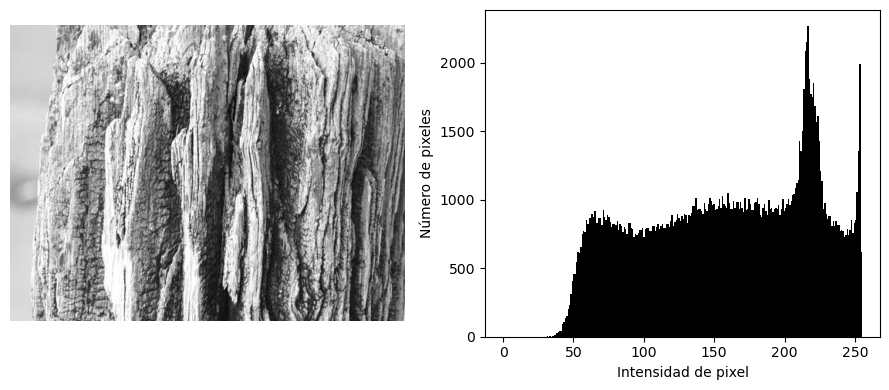

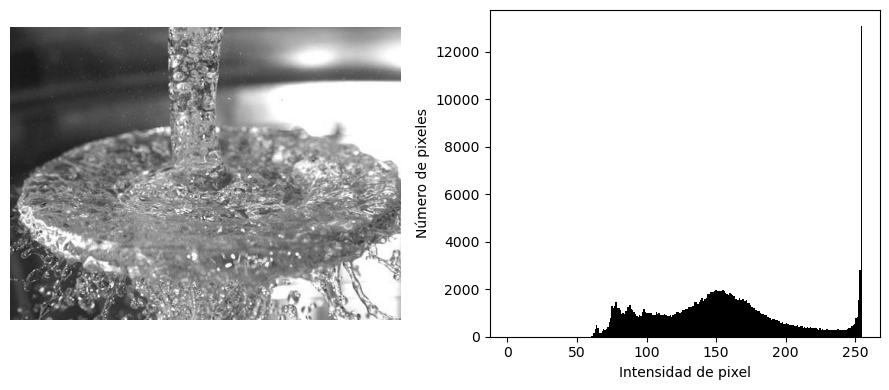

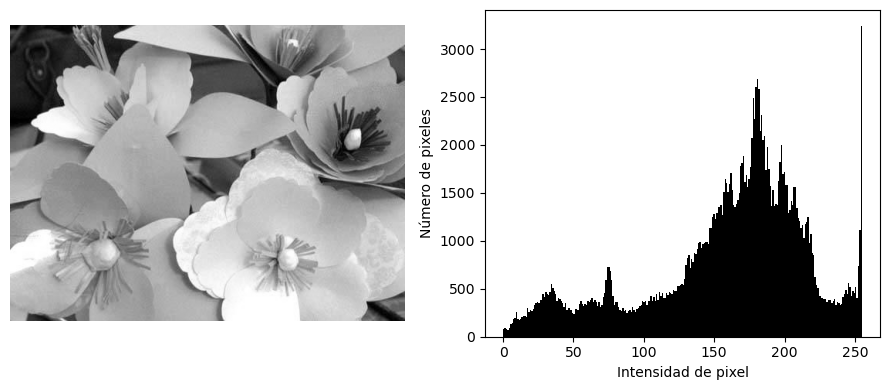

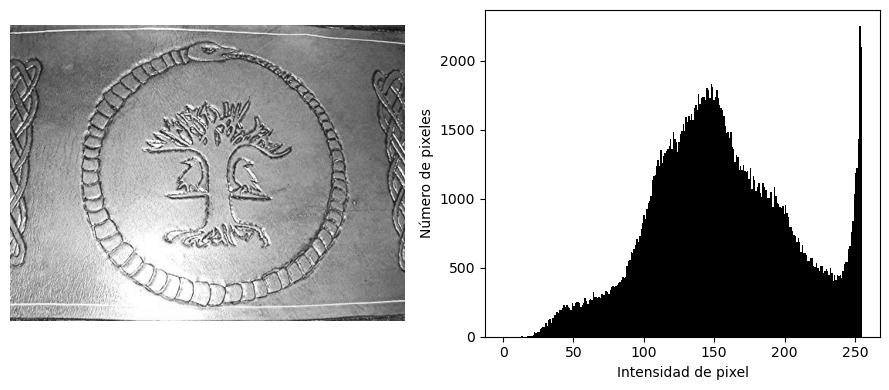

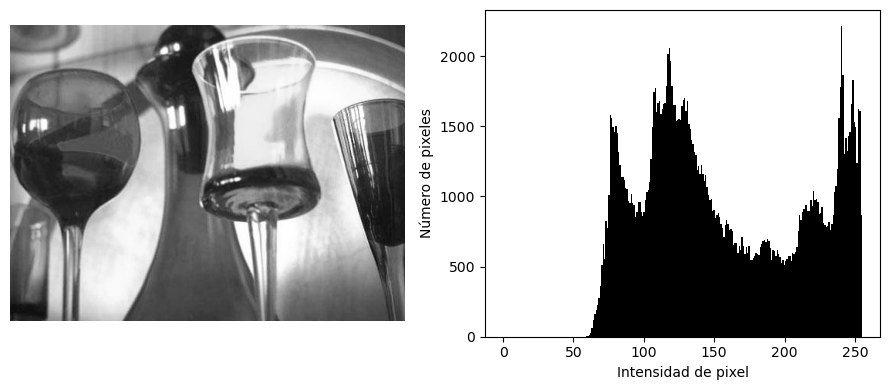

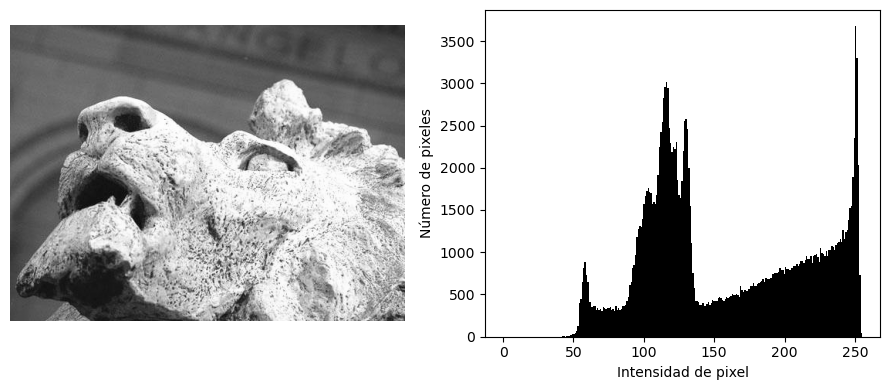

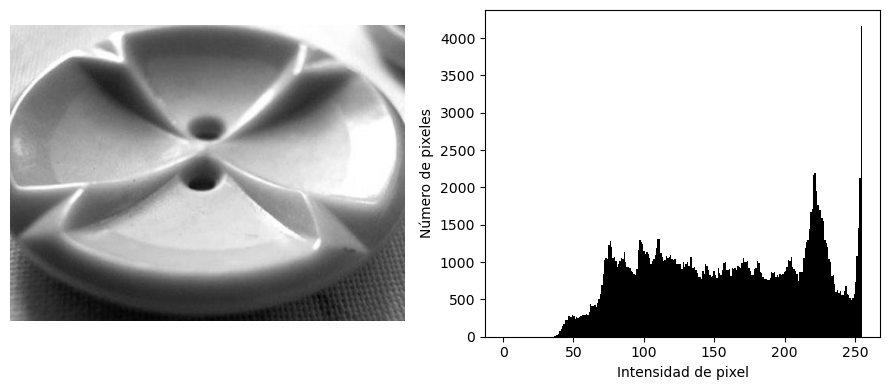

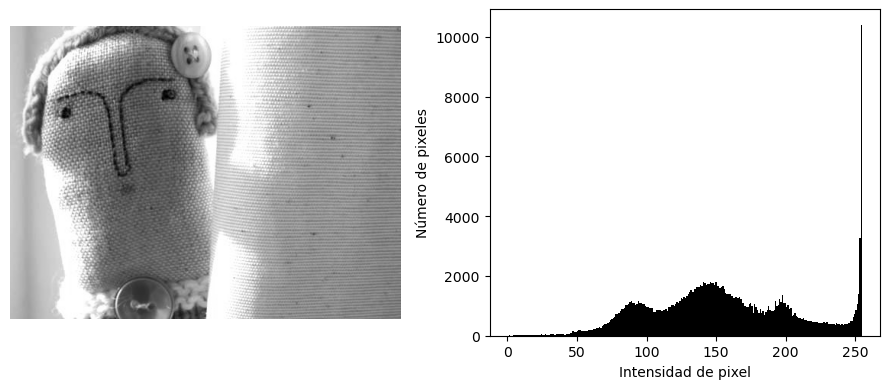

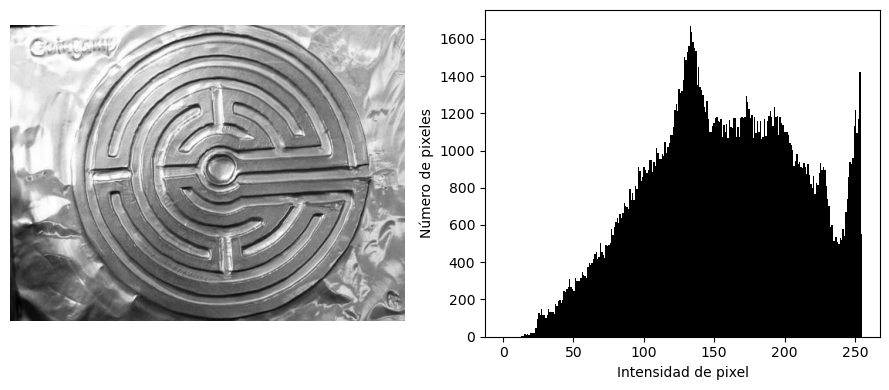

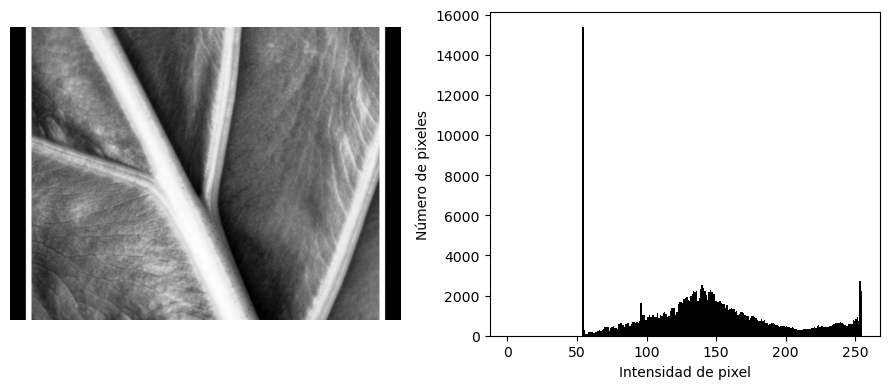

In [8]:
# Finalmente, mostramos una imagen y su histograma para cada categoría
for cat in categories:
    img = gray_images[cat][0]
    
    # Imagen
    plt.figure(figsize=(9, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    #plt.title(f"Ejemplo de imagen en '{cat}'", fontsize=14)
    plt.axis('off')
    
    # Histograma
    plt.subplot(1, 2, 2)
    plt.hist(img.ravel(), bins=256, range=(0, 255), color='black')
    #plt.title(f"Histograma de imagen en '{cat}'", fontsize=14)
    plt.xlabel("Intensidad de pixel")
    plt.ylabel("Número de pixeles")
    
    plt.tight_layout()
    plt.show()

### **3. Implementación de LBP**

Implementación manual del algoritmo de Patrones Binarios Locales. El algoritmo sigue estos pasos:

1.  Para cada pixel central, comparar su intensidad con 8 vecinos.

2.  Generar un patrón binario (1 si el vecino ≥ central, 0 en otro caso).

3.  Convertir el binario a decimal y reemplazar el pixel central.

In [9]:
# Bibliotecas necesarias para implementar LBP
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [10]:
# Primero definimos funciones auxiliares para calcular el valor LBP de cada pixel

# Función para obtener un patrón binario (1 si el vecino ≥ centro, 0 en otro caso).
def binary_pattern(img, center, x, y):

    new_value = 0
    if img[x][y] >= center:
        new_value = 1

    return new_value

# Función para calcular el valor LBP de un pixel (x, y)
def lbp_value(img, x, y):

    center = img[x][y]
    neighbors = []
    
    neighbors.append(binary_pattern(img, center, x-1, y-1))
    neighbors.append(binary_pattern(img, center, x-1, y))
    neighbors.append(binary_pattern(img, center, x-1, y + 1))
    neighbors.append(binary_pattern(img, center, x, y + 1))
    neighbors.append(binary_pattern(img, center, x + 1, y + 1))
    neighbors.append(binary_pattern(img, center, x + 1, y))
    neighbors.append(binary_pattern(img, center, x + 1, y-1))
    neighbors.append(binary_pattern(img, center, x, y-1))
     
    powers_of_2 = [1, 2, 4, 8, 16, 32, 64, 128]
    val = 0
    for i in range(len(neighbors)):
        val += neighbors[i] * powers_of_2[i]
        
    return val

In [11]:
# Finalmente, utilizamos las funciones anteriores para calcular el valor LBP de todos los pixeles en una imagen

def lbp(img):

    img_lbp = np.zeros(img.shape, np.uint8)
    # Recorremos la imagen y calculamos el valor LBP para cada pixel, evitando los bordes
    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            img_lbp[i, j] = lbp_value(img, i, j)

    return img_lbp

In [12]:
# Prueba con la primer imagen de la primer categoría
test = lbp(gray_images[categories[0]][0])
print("Algoritmo LBP aplicado a la primer imagen de la categoría 'wood':\n", test)


Algoritmo LBP aplicado a la primer imagen de la categoría 'wood':
 [[  0   0   0 ...   0   0   0]
 [  0 255 255 ...   3 243   0]
 [  0 143 143 ... 251 121   0]
 ...
 [  0 255 239 ...  60  60   0]
 [  0 255 231 ...  60  32   0]
 [  0   0   0 ...   0   0   0]]


### **4. Extracción de Características**

Convertir cada imagen LBP en un histograma de 256 bins (para valores 0-255).

Mostrar el histograma normalizado de una imagen por cada clase.


In [13]:
# Convertimos todas las imágenes a LBP
lbp_images = {}

print("Iniciando la conversión de imágenes a LBP...")

for cat, img_list in gray_images.items():
    lbp_images[cat] = [lbp(img) for img in img_list]

print(f"Conversión a LBP completada.\n")

Iniciando la conversión de imágenes a LBP...
Conversión a LBP completada.



Iniciando la extracción de características...
Extracción de características completada.



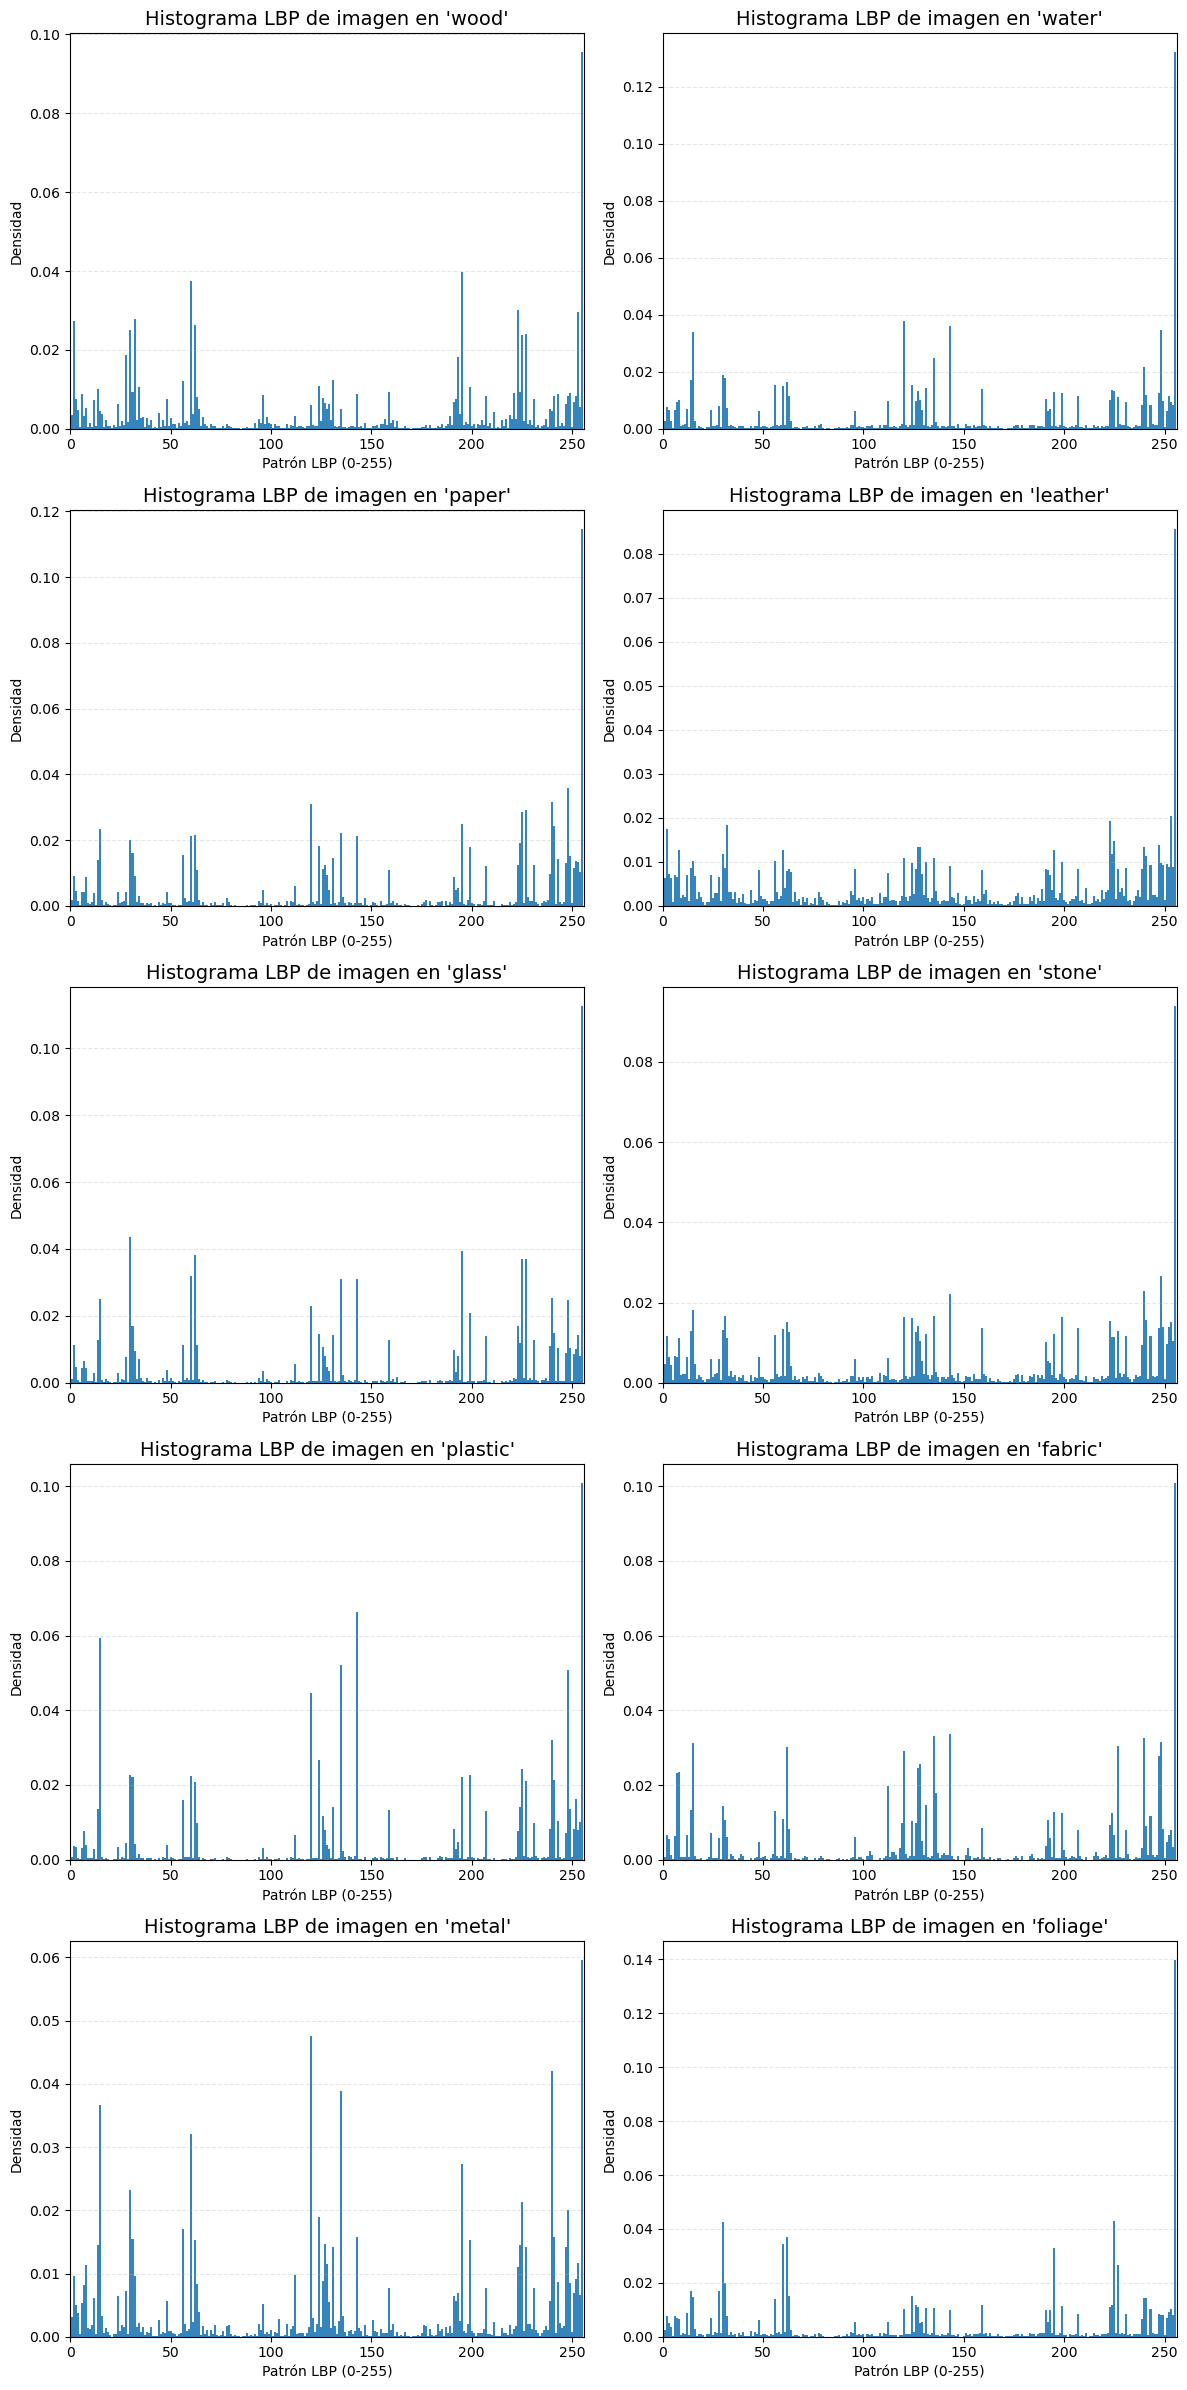

In [14]:
# Convertimos cada imagen LBP en un histograma de 256 bins
lbp_hists = {}

print("Iniciando la extracción de características...")

# Iteramos sobre todas las imágenes LBP por categoría
for cat, img_list in lbp_images.items():
    lbp_hists[cat] = []
    for img in img_list:
        # Con OpenCV, contamos cuántas veces aparece cada valor de pixel
        # Convertimos el histograma a un vector unidimensional y lo normalizamos
        # Finalmente, lo agregamos a la lista de histogramas de la categoría correspondiente 
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        hist = hist.flatten()
        hist_norm = hist / hist.sum()
        lbp_hists[cat].append(hist_norm)

print(f"Extracción de características completada.\n")

# Finalmente, mostramos el histograma LBP de la primer imagen de cada categoría
fig, axes = plt.subplots(5, 2, figsize=(12, 24))
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    ax.bar(np.arange(256), lbp_hists[cat][0], width=1.0, alpha=0.9)
    ax.set_title(f"Histograma LBP de imagen en '{cat}'", fontsize=14)
    ax.set_xlabel("Patrón LBP (0-255)")
    ax.set_ylabel("Densidad")
    ax.set_xlim([0, 256])
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### **5. Clasificación y Evaluación**

a) Divide los datos en entrenamiento (70%) y prueba (30%).

b) Usa un modelo simple como vecinos más cercanos (k-NN) o Máquina de Soporte Vectorial (SVM) sobre los vectores de características y entrena el modelo.

c) Calcula la exactitud en el conjunto de prueba.

d) Visualiza las imágenes LBP para entender qué patrones se están detectando.

e) Mostrar matriz de confusión.

In [15]:
# Bibliotecas para clasificar y evaluar los resultados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
# Dividimos los datos en entrenamiento y prueba 

# Separamos los datos en un arreglo de histogramas (X) y uno de etiquetas (y)
X = []
y = []
for cat, hists in lbp_hists.items():
    for h in hists:
        X.append(h)
        y.append(cat)
X = np.array(X)
y = np.array(y)

# Utilizamos train_test_split para dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Transformamos las etiquetas a números para que los modelos puedan procesarlas
# Escalamos los datos para un mejor funcionamiento de los modelos
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


In [17]:
# Utilizamos KNN para clasificar las imágenes basándonos en sus histogramas LBP

# Entrenamos los datos
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train_std, y_train_encoded)
y_pred_knn = knn.predict(X_test_std)

# Evaluamos la exactitud en el conjunto de prueba
print("Resultados de KNN:\n")
print(classification_report(y_test_encoded, y_pred_knn, target_names=le.classes_))

Resultados de KNN:

              precision    recall  f1-score   support

      fabric       0.17      0.22      0.19        23
     foliage       0.97      0.80      0.88        35
       glass       0.22      0.58      0.31        24
     leather       0.30      0.24      0.26        34
       metal       0.19      0.17      0.18        29
       paper       0.40      0.16      0.23        37
     plastic       0.43      0.33      0.38        30
       stone       0.43      0.39      0.41        33
       water       0.26      0.50      0.34        20
        wood       0.72      0.37      0.49        35

    accuracy                           0.37       300
   macro avg       0.41      0.38      0.37       300
weighted avg       0.44      0.37      0.38       300



In [18]:
# Utilizamos SVM para clasificar las imágenes basándonos en sus histogramas LBP

# Entrenamos los datos
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_std, y_train_encoded)
y_pred_svm = svm.predict(X_test_std)

# Evaluamos la exactitud en el conjunto de prueba
print("Resultados de SVM:\n")
print(classification_report(y_test_encoded, y_pred_svm, target_names=le.classes_))


Resultados de SVM:

              precision    recall  f1-score   support

      fabric       0.25      0.35      0.29        23
     foliage       0.97      0.89      0.93        35
       glass       0.31      0.54      0.39        24
     leather       0.38      0.32      0.35        34
       metal       0.23      0.21      0.22        29
       paper       0.40      0.22      0.28        37
     plastic       0.35      0.30      0.32        30
       stone       0.51      0.61      0.56        33
       water       0.48      0.55      0.51        20
        wood       0.65      0.57      0.61        35

    accuracy                           0.46       300
   macro avg       0.45      0.45      0.45       300
weighted avg       0.47      0.46      0.46       300



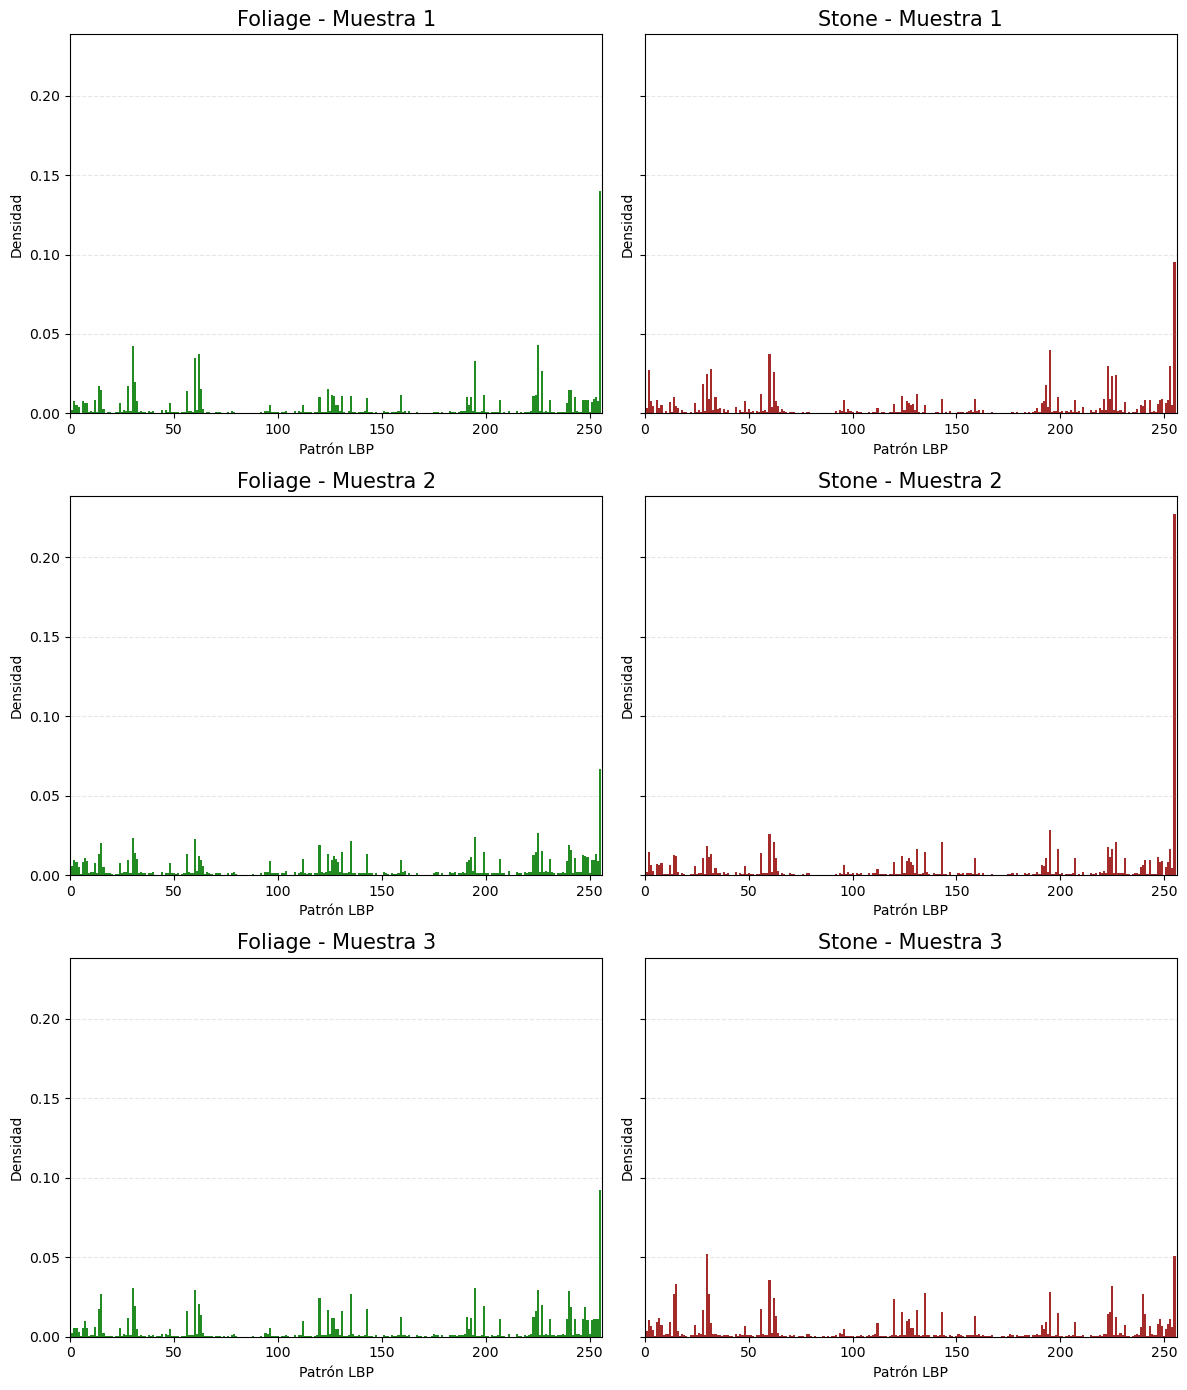

In [29]:
# Observemos los patrones LBP de las clases 'foliage' y 'stone' para distinguir por qué se clasificaron mejor

# Patrones LBP de 'foliage' y 'stone'
fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharey=True)

axes[0, 0].bar(np.arange(256), lbp_hists['foliage'][0], color='forestgreen', width=1.0)
axes[0, 0].set_title("Foliage - Muestra 1", fontsize=15)

axes[0, 1].bar(np.arange(256), lbp_hists['wood'][0], color='brown', width=1.0)
axes[0, 1].set_title("Stone - Muestra 1", fontsize=15)

axes[1, 0].bar(np.arange(256), lbp_hists['foliage'][1], color='forestgreen', width=1.0)
axes[1, 0].set_title("Foliage - Muestra 2", fontsize=15)

axes[1, 1].bar(np.arange(256), lbp_hists['wood'][1], color='brown', width=1.0)
axes[1, 1].set_title("Stone - Muestra 2", fontsize=15)

axes[2, 0].bar(np.arange(256), lbp_hists['foliage'][2], color='forestgreen', width=1.0)
axes[2, 0].set_title("Foliage - Muestra 3", fontsize=15)

axes[2, 1].bar(np.arange(256), lbp_hists['stone'][2], color='brown', width=1.0)
axes[2, 1].set_title("Stone - Muestra 3", fontsize=15)

for ax in axes.flat:
    ax.set_xlim([0, 256])
    ax.set_xlabel("Patrón LBP")
    ax.set_ylabel("Densidad")
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
    


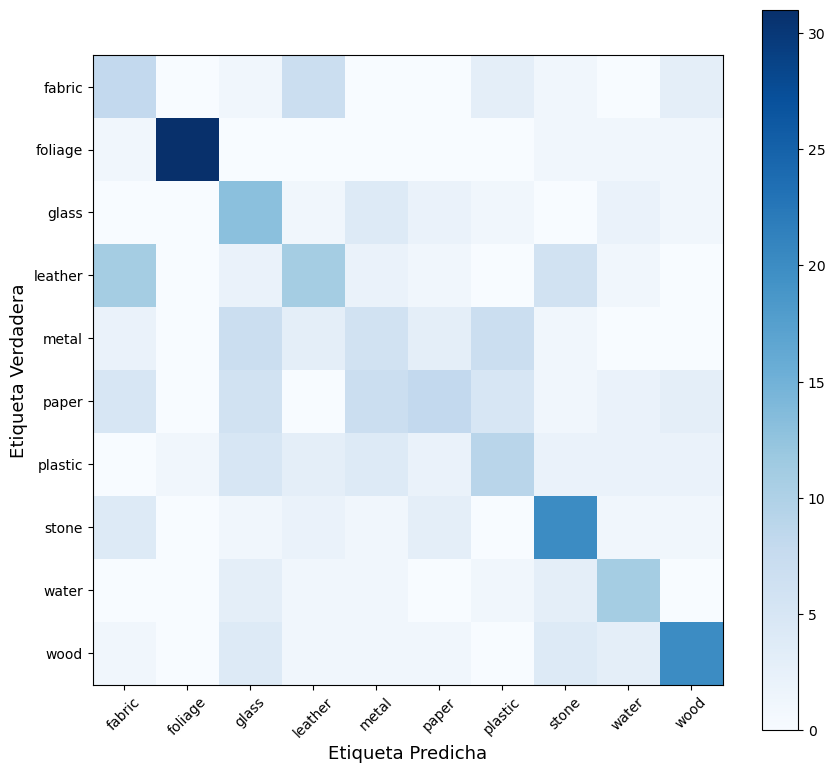

In [33]:
# Finalmente, mostramos las matrices de confusión para SVM (que fue el modelo con mejor desempeño)

# Matriz de confusión para SVM
cm_svm = confusion_matrix(y_test_encoded, y_pred_svm)

plt.figure(figsize=(9, 8))
plt.imshow(cm_svm, cmap=plt.cm.Blues)
#plt.title("Matriz de Confusión - SVM", fontsize=16)
plt.colorbar()

tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel("Etiqueta Predicha", fontsize=13)
plt.ylabel("Etiqueta Verdadera", fontsize=13)

plt.grid(False)
plt.tight_layout()
plt.show()

### **6. Repite los pasos 3, 4, 5 y 6 aplicando el algoritmo LBP con distintas configuraciones**

Ej: $[P = 16, R = 2]$ y $[P = 24, R = 3]$ y compara resultados.

In [21]:
# Bibliotecas necesarias: sk-image con LBP para distintos radios y vecinos
from skimage.feature import local_binary_pattern

In [22]:
# Convertimos las imágenes a LBP con la función local_binary_pattern de sk-image

# p = 16, r = 2 
lbp_images_p16_r2 = {}
for cat, img_list in gray_images.items():
    lbp_images_p16_r2[cat] = [local_binary_pattern(img, 16, 2, method='uniform') for img in img_list]

# p = 24, r = 3 (Uniform)
lbp_images_p24_r3 = {}
for cat, img_list in gray_images.items():
    lbp_images_p24_r3[cat] = [local_binary_pattern(img, 24, 3, method='uniform') for img in img_list]

In [23]:
# Ahora convertimos cada imagen LBP a un histograma de 256 bins para ambos casos

# Histogramas para p=16, r=2
lbp_hists_p16_r2 = {}

for cat, img_list in lbp_images_p16_r2.items():
    lbp_hists_p16_r2[cat] = []
    for img in img_list:
        hist, _ = np.histogram(img.ravel(), bins=18, range=(0, 18), density=True)
        lbp_hists_p16_r2[cat].append(hist)

# Histogramas para p=24, r=3
lbp_hists_p24_r3 = {}

for cat, img_list in lbp_images_p24_r3.items():
    lbp_hists_p24_r3[cat] = []
    for img in img_list:
        hist, _ = np.histogram(img.ravel(), bins=26, range=(0, 26), density=True)
        lbp_hists_p24_r3[cat].append(hist)

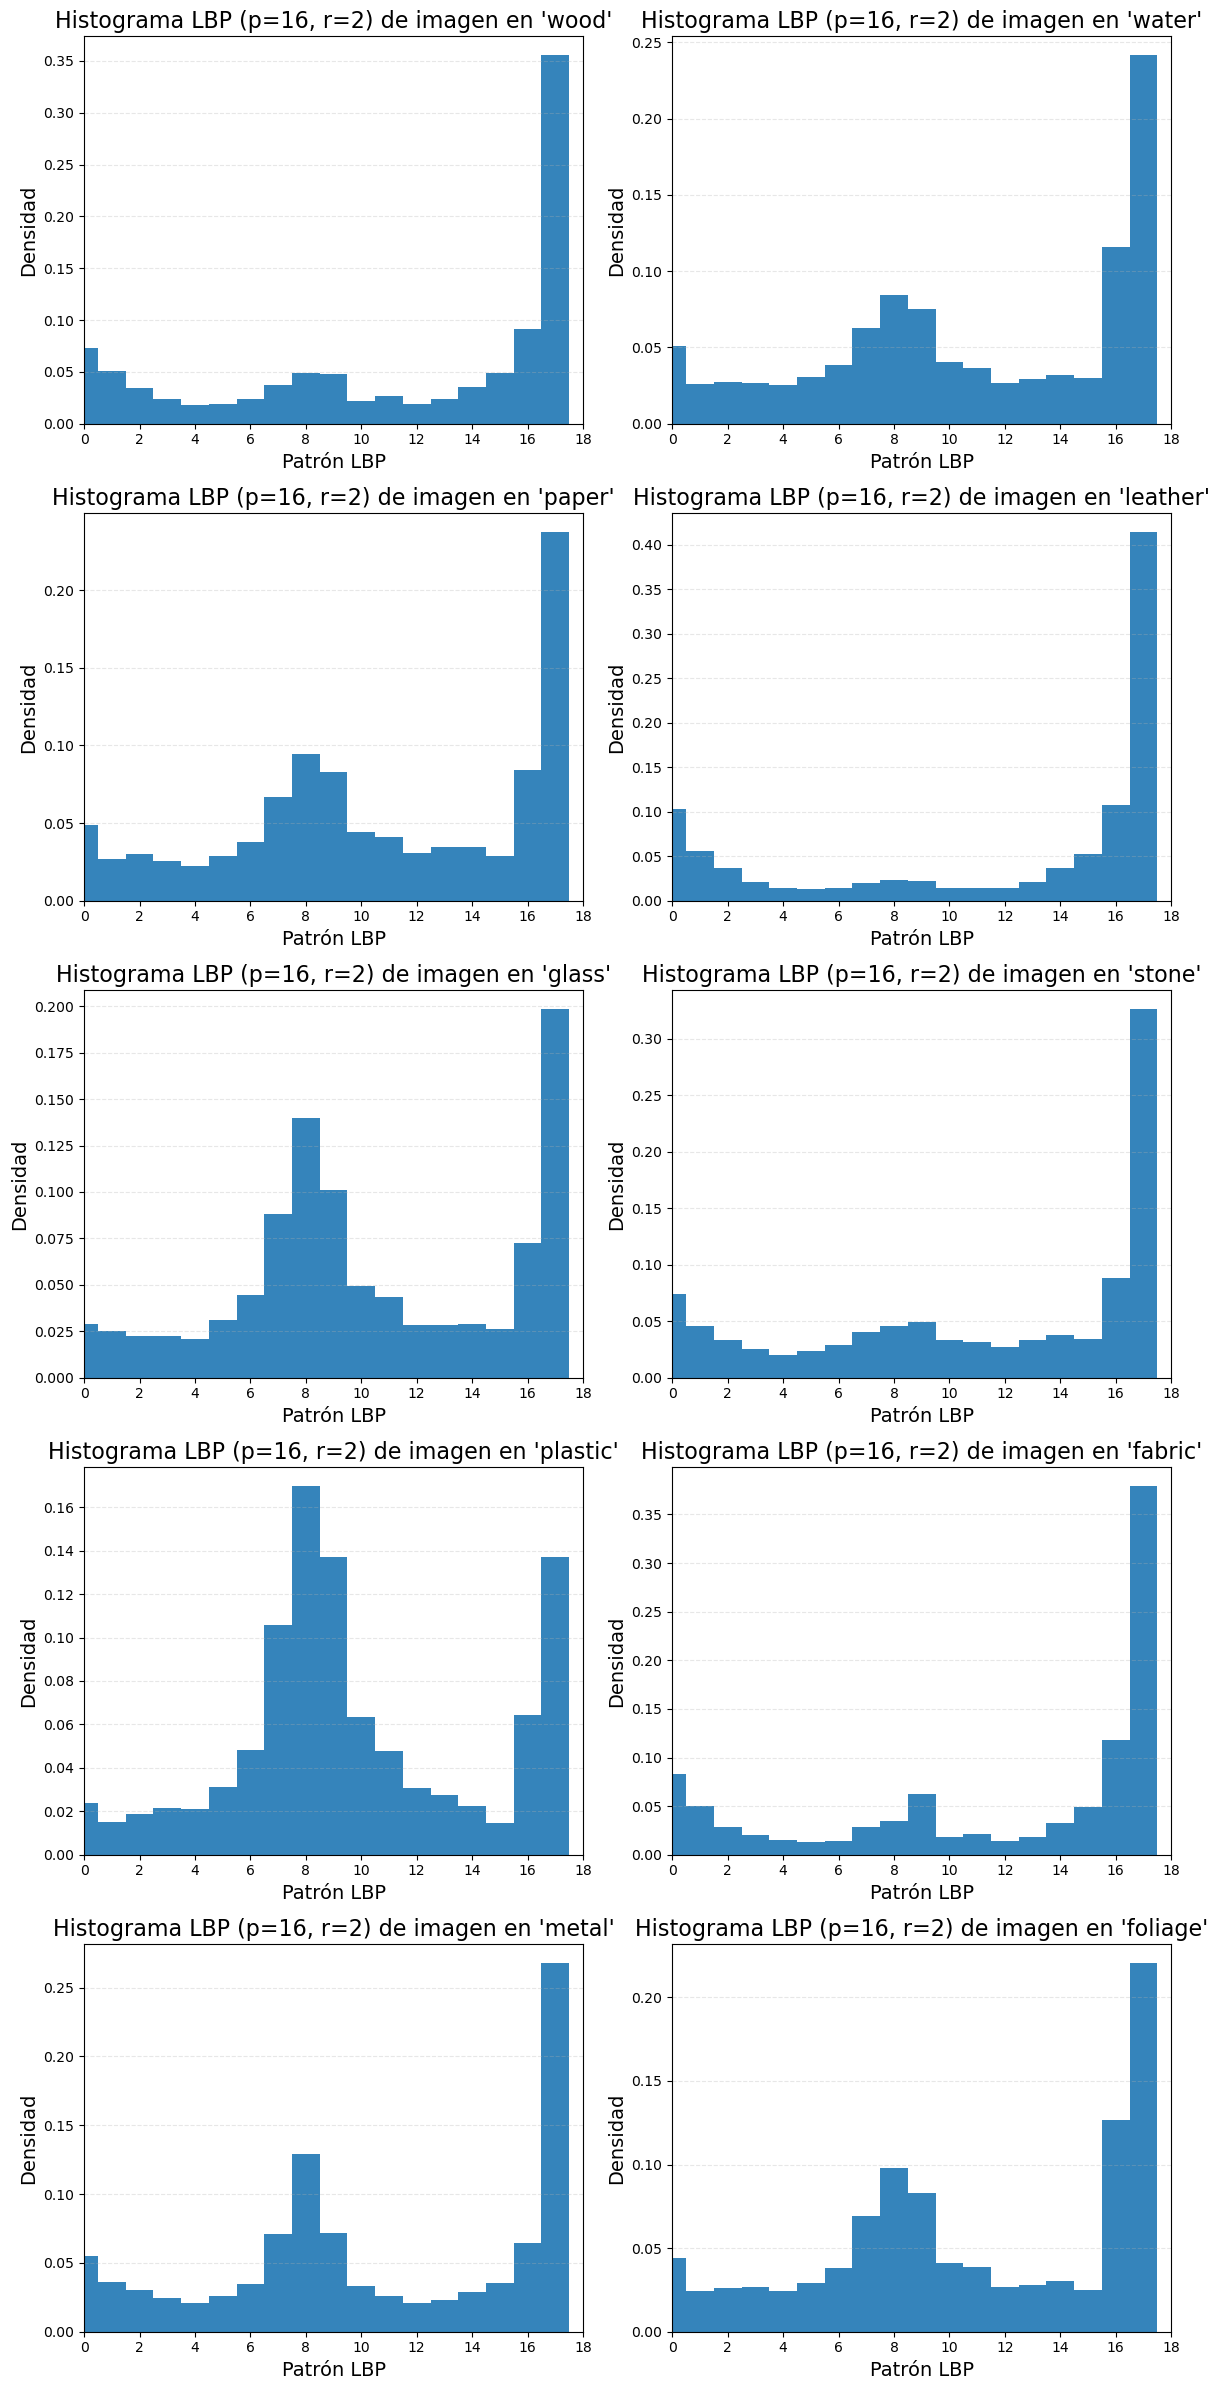

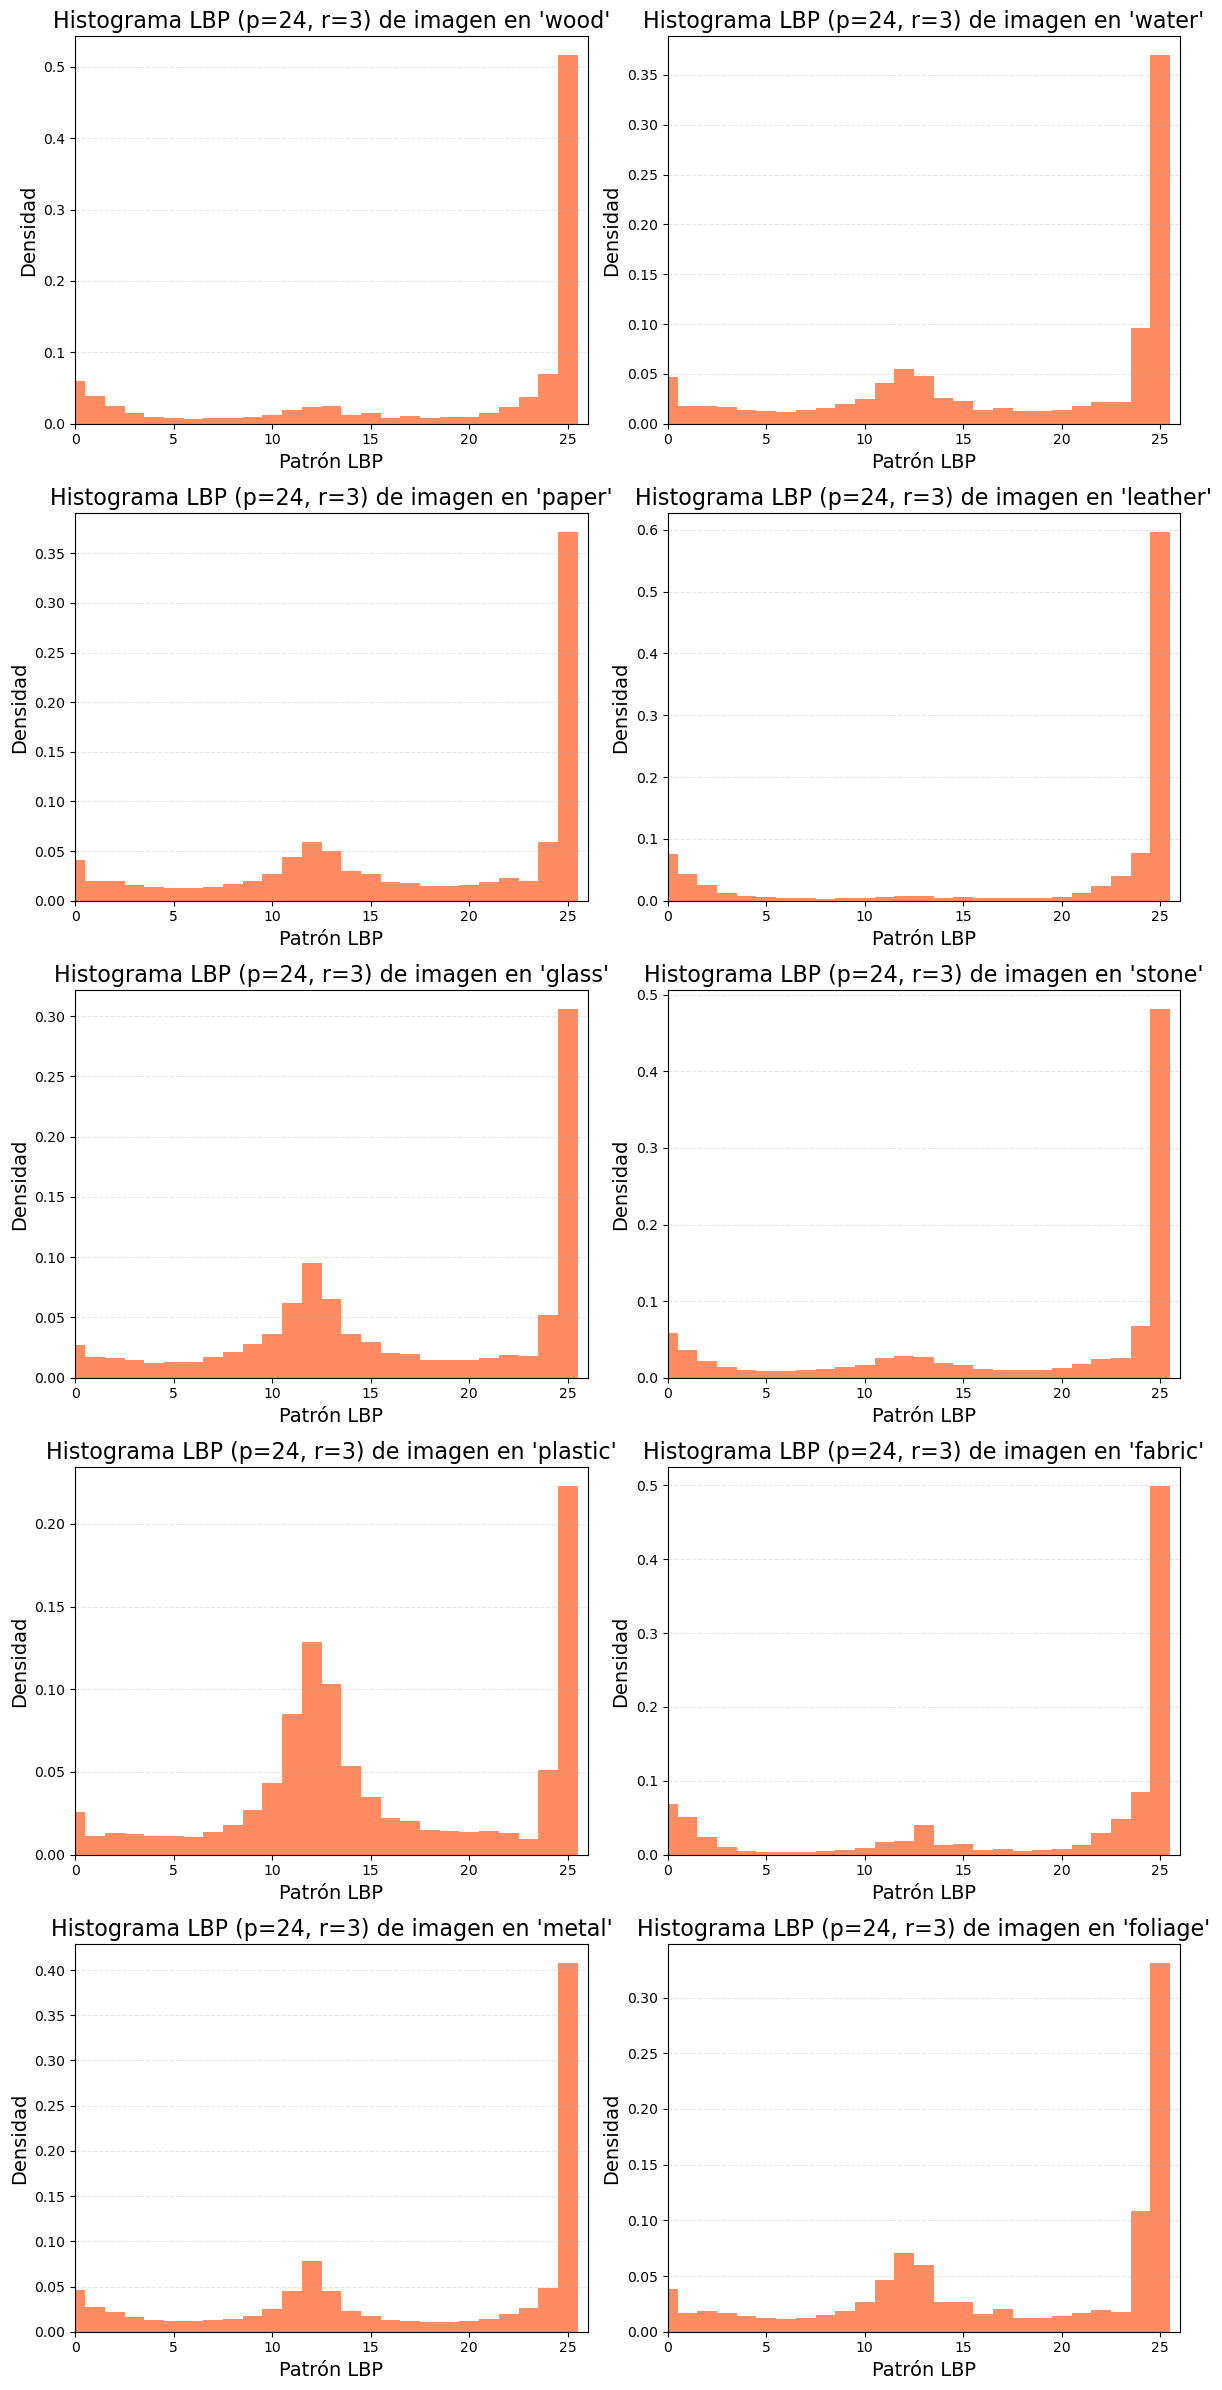

In [41]:
# Visualizamos los histogramas LBP con una imagen por categoría

# p=16, r=2
fig, axes = plt.subplots(5, 2, figsize=(12, 24))
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    ax.bar(np.arange(18), lbp_hists_p16_r2[cat][0], width=1.0, alpha=0.9)
    ax.set_title(f"Histograma LBP (p=16, r=2) de imagen en '{cat}'", fontsize=16)
    ax.set_xlabel("Patrón LBP", fontsize=14)
    ax.set_ylabel("Densidad", fontsize=14)
    ax.set_xlim([0, 18])
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# p=24, r=3
fig, axes = plt.subplots(5, 2, figsize=(12, 24))
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    ax.bar(np.arange(26), lbp_hists_p24_r3[cat][0], width=1.0, alpha=0.9, color='coral')
    ax.set_title(f"Histograma LBP (p=24, r=3) de imagen en '{cat}'", fontsize=16)
    ax.set_xlabel("Patrón LBP", fontsize=14)
    ax.set_ylabel("Densidad", fontsize=14)
    ax.set_xlim([0, 26])
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Esta vez sólo utilizaremos SVM para clasificar las imágenes y evaluar el rendimiento obtenido

# Dividimos los datos en entrenamiento y prueba

# Separamos los datos en un arreglo de histogramas (X) y uno de etiquetas (y)
X_p16_r2 = []
for cat, hists in lbp_hists_p16_r2.items():
    for h in hists:
        X_p16_r2.append(h)
X_p16_r2 = np.array(X_p16_r2)

X_p24_r3 = []
for cat, hists in lbp_hists_p24_r3.items():
    for h in hists:
        X_p24_r3.append(h)
X_p24_r3 = np.array(X_p24_r3)

# Utilizamos train_test_split para dividir los datos en entrenamiento y prueba
X_train_p16_r2, X_test_p16_r2, y_train_p16_r2, y_test_p16_r2 = train_test_split(X_p16_r2, y, test_size=0.2, random_state=42)
X_train_p24_r3, X_test_p24_r3, y_train_p24_r3, y_test_p24_r3 = train_test_split(X_p24_r3, y, test_size=0.2, random_state=42)

# Transformamos las etiquetas a números para que el modelo puedan procesarlas
# Escalamos los datos para un mejor funcionamiento del modelo
le = LabelEncoder()
y_train_encoded_p16_r2 = le.fit_transform(y_train_p16_r2)
y_test_encoded_p16_r2 = le.transform(y_test_p16_r2)
y_train_encoded_p24_r3 = le.fit_transform(y_train_p24_r3)
y_test_encoded_p24_r3 = le.transform(y_test_p24_r3)

sc = StandardScaler()
X_train_std_p16_r2 = sc.fit_transform(X_train_p16_r2)
X_test_std_p16_r2 = sc.transform(X_test_p16_r2)
X_train_std_p24_r3 = sc.fit_transform(X_train_p24_r3)
X_test_std_p24_r3 = sc.transform(X_test_p24_r3)

# Entrenamos los datos con SVM
svm_p16_r2 = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_p16_r2.fit(X_train_std_p16_r2, y_train_encoded_p16_r2)
y_pred_p16_r2 = svm_p16_r2.predict(X_test_std_p16_r2)

svm_p24_r3 = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_p24_r3.fit(X_train_std_p24_r3, y_train_encoded_p24_r3)
y_pred_p24_r3 = svm_p24_r3.predict(X_test_std_p24_r3)

In [26]:
# Evaluamos la exactitud en el conjunto de prueba para ambos casos
print("Resultados de SVM (p=16, r=2):\n")
print(classification_report(y_test_encoded_p16_r2, y_pred_p16_r2, target_names=le.classes_))

Resultados de SVM (p=16, r=2):

              precision    recall  f1-score   support

      fabric       0.19      0.23      0.21        13
     foliage       0.58      0.67      0.62        21
       glass       0.33      0.33      0.33        15
     leather       0.31      0.43      0.36        21
       metal       0.14      0.09      0.11        23
       paper       0.67      0.37      0.48        27
     plastic       0.42      0.40      0.41        25
       stone       0.50      0.59      0.54        22
       water       0.26      0.38      0.31        13
        wood       0.56      0.50      0.53        20

    accuracy                           0.41       200
   macro avg       0.40      0.40      0.39       200
weighted avg       0.42      0.41      0.40       200



In [27]:
print("Resultados de SVM (p=24, r=3):\n")
print(classification_report(y_test_encoded_p24_r3, y_pred_p24_r3, target_names=le.classes_))

Resultados de SVM (p=24, r=3):

              precision    recall  f1-score   support

      fabric       0.10      0.15      0.12        13
     foliage       0.57      0.62      0.59        21
       glass       0.19      0.33      0.24        15
     leather       0.39      0.33      0.36        21
       metal       0.20      0.13      0.16        23
       paper       0.67      0.22      0.33        27
     plastic       0.50      0.44      0.47        25
       stone       0.48      0.68      0.57        22
       water       0.28      0.38      0.32        13
        wood       0.56      0.45      0.50        20

    accuracy                           0.38       200
   macro avg       0.39      0.37      0.37       200
weighted avg       0.42      0.38      0.38       200



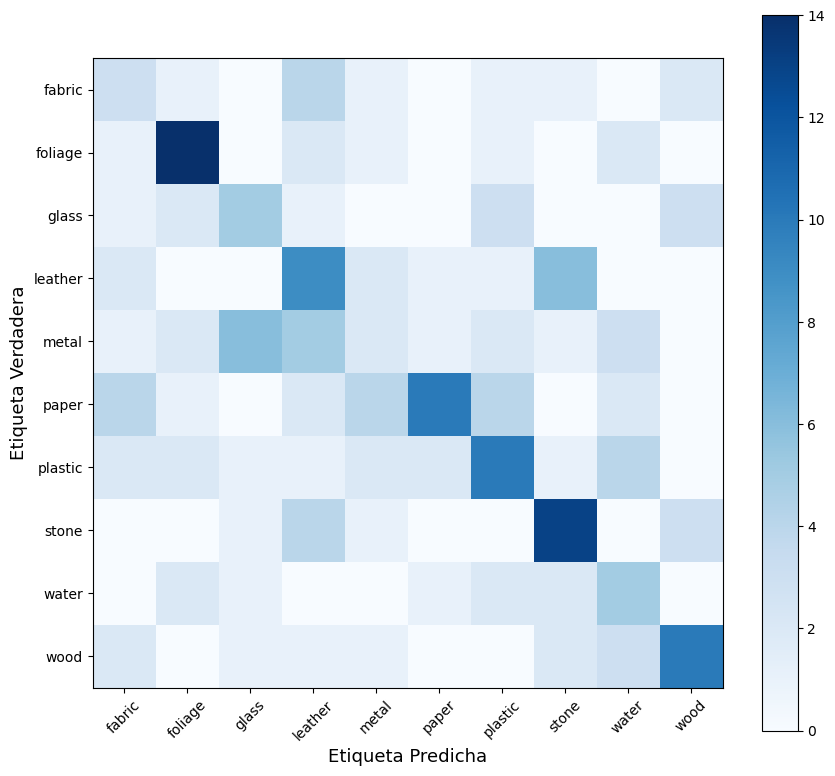

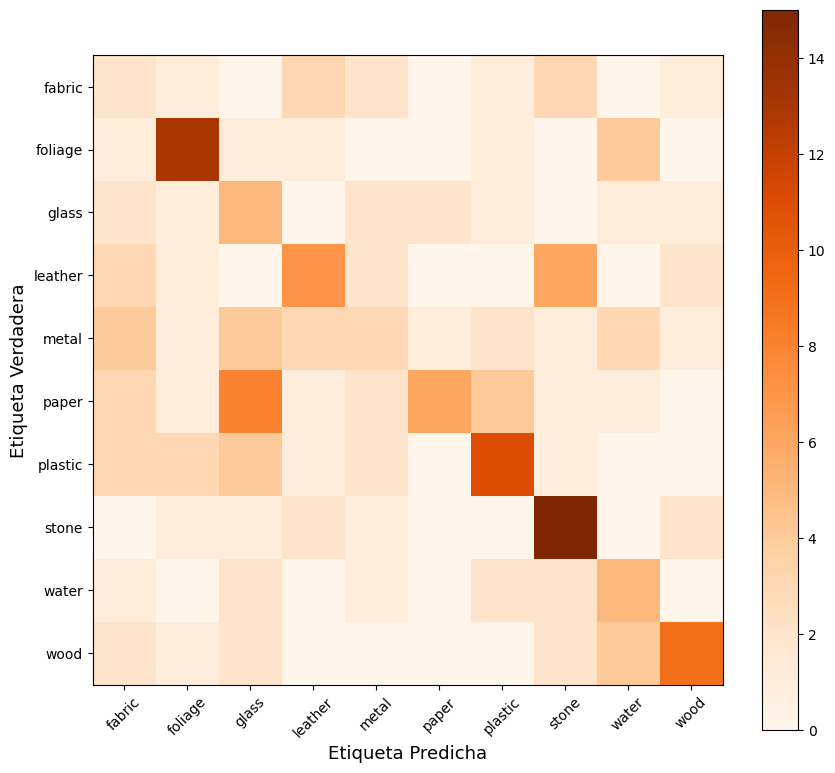

In [34]:
# Visualizamos las matrices de confusión para ambos casos

# Matriz de confusión para p=16, r=2
cm_p16_r2 = confusion_matrix(y_test_encoded_p16_r2, y_pred_p16_r2)
plt.figure(figsize=(9, 8))
plt.imshow(cm_p16_r2, cmap=plt.cm.Blues)
#plt.title("Matriz de Confusión (p=16, r=2)", fontsize=16)
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel("Etiqueta Predicha", fontsize=13)
plt.ylabel("Etiqueta Verdadera", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()

# Matriz de confusión para p=24, r=3
cm_p24_r3 = confusion_matrix(y_test_encoded_p24_r3, y_pred_p24_r3)
plt.figure(figsize=(9, 8))
plt.imshow(cm_p24_r3, cmap=plt.cm.Oranges)
#plt.title("Matriz de Confusión (p=24, r=3)", fontsize=16)
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel("Etiqueta Predicha", fontsize=13)
plt.ylabel("Etiqueta Verdadera", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()